In [1]:
list.of.packages <- c("tidyverse","fixest","stargazer","broom","data.table","patchwork","ggpubr")
new.packages <- list.of.packages[!(list.of.packages %in% installed.packages()[,"Package"])]
if(length(new.packages)) install.packages(new.packages, repos = "http://cran.us.r-project.org")

invisible(lapply(list.of.packages, library, character.only = TRUE))

options(repr.matrix.max.rows=500, repr.matrix.max.cols=500)  

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 



Attachement du package : ‘data.table’


Les objets suivants sont masqués depuis ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


Les objet

In [2]:
varT <- c("T_Bin_inf17_Nhours_on","T_Bin_17_21_Nhours_on",
          "T_Bin_21_23_Nhours_on","T_Bin_23_25_Nhours_on",
          "T_Bin_25_27_Nhours_on","T_Bin_27_29_Nhours_on", 
          "T_Bin_29_31_Nhours_on","T_Bin_31_33_Nhours_on", 
          "T_Bin_sup33_Nhours_on")
varWB <- c("WB_Bin_inf14_Nhours_on","WB_Bin_14_16_Nhours_on",
           "WB_Bin_16_18_Nhours_on","WB_Bin_18_20_Nhours_on",
           "WB_Bin_20_22_Nhours_on","WB_Bin_22_24_Nhours_on",
           "WB_Bin_24_26_Nhours_on","WB_Bin_26_28_Nhours_on", 
           "WB_Bin_sup28_Nhours_on")

T_bins_labels_pretty <- c("≤17°C", "(17,21]", "(21,23]", "(23,25]", "(25,27]", "(27,29]", "(29,31]", "(31,33]", ">33°C")

WB_bins_labels_pretty <- c("≤14°C","(14,16]","(16,18]","(18,20]","(20,22]","(22,24]","(24,26]","(26,28]",">28°C")

dict_levels_T_10 <- setNames(paste0("T:",T_bins_labels_pretty), paste0(varT,10))
dict_levels_WB_10 <- setNames(paste0("WBGT: ",WB_bins_labels_pretty),paste0(varWB,10))

dict_levels_T_20 <- setNames(paste0("T:",T_bins_labels_pretty), paste0(varT,20))
dict_levels_WB_20 <- setNames(paste0("WBGT: ",WB_bins_labels_pretty),paste0(varWB,20))

dict_levels_T_30 <- setNames(paste0("T:",T_bins_labels_pretty), paste0(varT,30))
dict_levels_WB_30 <- setNames(paste0("WBGT: ",WB_bins_labels_pretty),paste0(varWB,30))

dict <- c(dict_levels_T_10, dict_levels_WB_10,
          dict_levels_T_20, dict_levels_WB_20,
          dict_levels_T_30, dict_levels_WB_30)

# Children

In [3]:
df_children <- fread("./2_Regression_datasets/output/df_reg_children.csv")
sprintf("%i rows x %i columns", nrow(df_children), ncol(df_children))
head(df_children,2)

[1] "281812 rows x 321 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Mother_id,Child_id,Resp_nb,Interview_month,Interview_year,Measured_date_CDC,Measured_date,Measured_day,Measured_month,Measured_year,Birth_month,Birth_year,Child_female,Child_birth_order,Child_alive_age_month,Child_hemo_level_alti,Child_weight_for_height_zscore,Child_diarrhea,Child_fever,Child_cough,Child_still_breastfeeding,Child_given_plain_water,Child_given_juice,Child_given_milk,Child_given_baby_formula,Child_given_fortified_baby_food,Child_given_soup,Child_given_other_liquid,Child_given_chicken_duck_birds,Child_given_bread_noodles_grains,Child_given_potatoes_cassava_tubers,Child_given_eggs,Child_given_pumkins_carrots_squash,Child_given_green_vegetables,Child_given_mangoes_papaya_vitaminAfruits,Child_given_other_fruits,Child_given_liver_heart_organs,Child_given_fish_sellfish,Child_given_beans_peas_lentils_nuts,Child_given_cheese_yogurt_milk_products,Child_given_other_solid_semisolid_food,Child_given_other_meat,Child_given_yogurt,Child_iron_supplem_7d,Mother_no_educ,Mother_prim_educ,Mother_second_educ,Mother_higher_educ,Mother_hindu,Mother_muslim,Mother_not_hindu_nor_muslim,Mother_ethni_SC,Mother_ethni_ST,Mother_ethni_OBC,Mother_ethni_other,Mother_height,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,Interview_cdc,Wasted,Age_rounded,Children_anemia,Child_severe_anemia,Child_moderate_anemia,Child_mild_anemia,Child_no_anemia,Season,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_

In [4]:
df_reg_children <- df_children %>%
                            mutate(across(ends_with("on30"), ~ . * 1/3),
                                   across(ends_with("on20"), ~ . * 1/2))
sprintf("%i rows x %i columns", nrow(df_reg_children), ncol(df_reg_children))
head(df_reg_children,2)

[1] "281812 rows x 321 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Mother_id,Child_id,Resp_nb,Interview_month,Interview_year,Measured_date_CDC,Measured_date,Measured_day,Measured_month,Measured_year,Birth_month,Birth_year,Child_female,Child_birth_order,Child_alive_age_month,Child_hemo_level_alti,Child_weight_for_height_zscore,Child_diarrhea,Child_fever,Child_cough,Child_still_breastfeeding,Child_given_plain_water,Child_given_juice,Child_given_milk,Child_given_baby_formula,Child_given_fortified_baby_food,Child_given_soup,Child_given_other_liquid,Child_given_chicken_duck_birds,Child_given_bread_noodles_grains,Child_given_potatoes_cassava_tubers,Child_given_eggs,Child_given_pumkins_carrots_squash,Child_given_green_vegetables,Child_given_mangoes_papaya_vitaminAfruits,Child_given_other_fruits,Child_given_liver_heart_organs,Child_given_fish_sellfish,Child_given_beans_peas_lentils_nuts,Child_given_cheese_yogurt_milk_products,Child_given_other_solid_semisolid_food,Child_given_other_meat,Child_given_yogurt,Child_iron_supplem_7d,Mother_no_educ,Mother_prim_educ,Mother_second_educ,Mother_higher_educ,Mother_hindu,Mother_muslim,Mother_not_hindu_nor_muslim,Mother_ethni_SC,Mother_ethni_ST,Mother_ethni_OBC,Mother_ethni_other,Mother_height,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,Interview_cdc,Wasted,Age_rounded,Children_anemia,Child_severe_anemia,Child_moderate_anemia,Child_mild_anemia,Child_no_anemia,Season,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_

# Women

In [5]:
df_women <- fread("./2_Regression_datasets/output/df_reg_women.csv")
sprintf("%i rows x %i columns", nrow(df_women), ncol(df_women))
head(df_women,2)

[1] "973462 rows x 330 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Women_id,Resp_nb,Interview_month,Interview_year,Interview_day,Measured_date_CDC,Measured_date,Current_age,Age_group,Religion_hindu,Religion_muslim,Religion_not_hindu_nor_muslim,Ethni_SC,Ethni_ST,Ethni_OBC,Ethni_other,N_year_educ,Smoker,Health_insurance,Currently_pregnant,Blood_hemo_level_alti,Blood_pressure_systo,Blood_pressure_diasto,Blood_glucose_level,Body_mass_index,Diet_milk_curd_daily,Diet_milk_curd_week,Diet_milk_curd_oc,Diet_milk_curd_never,Diet_pulses_beans_daily,Diet_pulses_beans_week,Diet_pulses_beans_oc,Diet_pulses_beans_never,Diet_green_veg_daily,Diet_green_veg_week,Diet_green_veg_oc,Diet_green_veg_never,Diet_fruits_daily,Diet_fruits_week,Diet_fruits_oc,Diet_fruits_never,Diet_eggs_daily,Diet_eggs_week,Diet_eggs_oc,Diet_eggs_never,Diet_fish_daily,Diet_fish_week,Diet_fish_oc,Diet_fish_never,Diet_chicken_meat_daily,Diet_chicken_meat_week,Diet_chicken_meat_oc,Diet_chicken_meat_never,Diet_fried_food_daily,Diet_fried_food_week,Diet_fried_food_oc,Diet_fried_food_never,Diet_aerated_drinks_daily,Diet_aerated_drinks_week,Diet_aerated_drinks_oc,Diet_aerated_drinks_never,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,cell_x.x,cell_y.x,cell_x.y,cell_y.y,Measured_month,Measured_year,Women_anemia,Women_severe_anemia,Women_moderate_anemia,Women_mild_anemia,Women_no_anemia,BMI_category,Blood_hypertension,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_on20,T_MaxBin_31_33_Ndays_on20,T

In [6]:
df_reg_women <- df_women %>%
                            mutate(across(ends_with("on30"), ~ . * 1/3),
                                   across(ends_with("on20"), ~ . * 1/2))

# Men

In [7]:
df_men <- fread("./2_Regression_datasets/output/df_reg_men.csv")
sprintf("%i rows x %i columns", nrow(df_men), ncol(df_men))
head(df_men,2)

[1] "150101 rows x 330 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Men_id,Resp_nb,Interview_month,Interview_year,Interview_day,Measured_date_CDC,Measured_date,Current_age,Age_group,Religion_hindu,Religion_muslim,Religion_not_hindu_nor_muslim,Ethni_SC,Ethni_ST,Ethni_OBC,Ethni_other,N_year_educ,Smoker,Health_insurance,Profession,Blood_pressure_systo,Blood_pressure_diasto,Blood_glucose_level,Diet_milk_curd_daily,Diet_milk_curd_week,Diet_milk_curd_oc,Diet_milk_curd_never,Diet_pulses_beans_daily,Diet_pulses_beans_week,Diet_pulses_beans_oc,Diet_pulses_beans_never,Diet_green_veg_daily,Diet_green_veg_week,Diet_green_veg_oc,Diet_green_veg_never,Diet_fruits_daily,Diet_fruits_week,Diet_fruits_oc,Diet_fruits_never,Diet_eggs_daily,Diet_eggs_week,Diet_eggs_oc,Diet_eggs_never,Diet_fish_daily,Diet_fish_week,Diet_fish_oc,Diet_fish_never,Diet_chicken_meat_daily,Diet_chicken_meat_week,Diet_chicken_meat_oc,Diet_chicken_meat_never,Diet_fried_food_daily,Diet_fried_food_week,Diet_fried_food_oc,Diet_fried_food_never,Diet_aerated_drinks_daily,Diet_aerated_drinks_week,Diet_aerated_drinks_oc,Diet_aerated_drinks_never,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Blood_hemo_level_alti,Body_mass_index,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,cell_x.x,cell_y.x,cell_x.y,cell_y.y,Measured_month,Measured_year,Men_anemia,Men_severe_anemia,Men_moderate_anemia,Men_mild_anemia,Men_no_anemia,BMI_category,Blood_hypertension,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_on20,T_MaxBin_31_33_Ndays_on20,T_MaxBin_27_29_Ndays_

In [8]:
df_reg_men <- df_men %>%
                            mutate(across(ends_with("on30"), ~ . * 1/3),
                                   across(ends_with("on20"), ~ . * 1/2))

# Hemoglobin level

In [9]:
fe_reg <- function(df,Y_var,T_var,N_days,controls, FE){
    if (T_var == "T"){
        varT <- c("T_Bin_inf17_Nhours_on",#"T_Bin_17_21_Nhours_on",
                  "T_Bin_21_23_Nhours_on","T_Bin_23_25_Nhours_on",
                  "T_Bin_25_27_Nhours_on","T_Bin_27_29_Nhours_on", 
                  "T_Bin_29_31_Nhours_on","T_Bin_31_33_Nhours_on", 
                  "T_Bin_sup33_Nhours_on")
        varT_d <- paste0(varT, N_days, collapse = " + ")
    }
    else{varT <- c("WB_Bin_inf14_Nhours_on","WB_Bin_14_16_Nhours_on",
                   "WB_Bin_18_20_Nhours_on",
                   "WB_Bin_20_22_Nhours_on","WB_Bin_22_24_Nhours_on",
                   "WB_Bin_24_26_Nhours_on","WB_Bin_26_28_Nhours_on", 
                   "WB_Bin_sup28_Nhours_on")
         varT_d <- paste0(varT, N_days, collapse = " + ")

        }
    P_var <- paste0("P_tot_",N_days)
    form <- paste0(Y_var," ~ ",varT_d, "+", P_var, controls, FE)
    #print(form)
    feols(formula(form),
          vcov = ~District_ID,                    
          df)
}

In [10]:
child_controls <-"+ Child_female + Child_birth_order + Child_alive_age_month +
                    Mother_prim_educ + Mother_second_educ + Mother_higher_educ +
                    Mother_muslim + Mother_not_hindu_nor_muslim  + 
                    Mother_ethni_SC + Mother_ethni_ST + Mother_ethni_OBC +
                    Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                    Urban "

In [11]:
adults_controls <- "+ Current_age + N_year_educ + Smoker + Health_insurance + 
                      Religion_muslim + Religion_not_hindu_nor_muslim + 
                      Ethni_SC + Ethni_ST + Ethni_OBC +
                      Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                      Urban "

In [12]:
FE <- "|District_ID^Measured_month + District_ID^Measured_year"

## 30 days

In [13]:
reg_children_T_30 <- fe_reg(df_reg_children,"Child_hemo_level_alti","T",30,child_controls,FE)
reg_women_T_30 <- fe_reg(df_reg_women,"Blood_hemo_level_alti","T",30,adults_controls,FE)
reg_men_T_30 <- fe_reg(df_reg_men,"Blood_hemo_level_alti","T",30,adults_controls,FE)

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 9,536 observations removed because of NA values (RHS: 9,536).
       13/1 fixed-effect singletons were removed (13 observations).



In [14]:
reg_children_WB_30 <- fe_reg(df_reg_children,"Child_hemo_level_alti","WB",30,child_controls,FE)
reg_women_WB_30 <- fe_reg(df_reg_women,"Blood_hemo_level_alti","WB",30,adults_controls,FE)
reg_men_WB_30 <- fe_reg(df_reg_men,"Blood_hemo_level_alti","WB",30,adults_controls,FE)

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 9,536 observations removed because of NA values (RHS: 9,536).
       13/1 fixed-effect singletons were removed (13 observations).



## 20 days

In [15]:
reg_children_T_20 <- fe_reg(df_reg_children,"Child_hemo_level_alti","T",20,child_controls,FE)
reg_women_T_20 <- fe_reg(df_reg_women,"Blood_hemo_level_alti","T",20,adults_controls,FE)
reg_men_T_20 <- fe_reg(df_reg_men,"Blood_hemo_level_alti","T",20,adults_controls,FE)

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 9,536 observations removed because of NA values (RHS: 9,536).
       13/1 fixed-effect singletons were removed (13 observations).



In [16]:
reg_children_WB_20 <- fe_reg(df_reg_children,"Child_hemo_level_alti","WB",20,child_controls,FE)
reg_women_WB_20 <- fe_reg(df_reg_women,"Blood_hemo_level_alti","WB",20,adults_controls,FE)
reg_men_WB_20 <- fe_reg(df_reg_men,"Blood_hemo_level_alti","WB",20,adults_controls,FE)

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 9,536 observations removed because of NA values (RHS: 9,536).
       13/1 fixed-effect singletons were removed (13 observations).



## 10 days

In [17]:
reg_children_T_10 <- fe_reg(df_reg_children,"Child_hemo_level_alti","T",10,child_controls,FE)
reg_women_T_10 <- fe_reg(df_reg_women,"Blood_hemo_level_alti","T",10,adults_controls,FE)
reg_men_T_10 <- fe_reg(df_reg_men,"Blood_hemo_level_alti","T",10,adults_controls,FE)

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 9,536 observations removed because of NA values (RHS: 9,536).
       13/1 fixed-effect singletons were removed (13 observations).



In [18]:
reg_children_WB_10 <- fe_reg(df_reg_children,"Child_hemo_level_alti","WB",10,child_controls,FE)
reg_women_WB_10 <- fe_reg(df_reg_women,"Blood_hemo_level_alti","WB",10,adults_controls,FE)
reg_men_WB_10 <- fe_reg(df_reg_men,"Blood_hemo_level_alti","WB",10,adults_controls,FE)

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 9,536 observations removed because of NA values (RHS: 9,536).
       13/1 fixed-effect singletons were removed (13 observations).



# Extract coefs for plotting

In [19]:
extract_coefs_T <- function(reg,cat,N_days){
        coef_tab_estim <- as.data.frame(rbind(tidy(reg,conf.int=TRUE)%>%
                                                 filter(term==paste0("T_Bin_inf17_Nhours_on",N_days))%>% 
                                                 mutate(group=cat,
                                                        specifi= paste0(N_days, " days"),
                                                        label = "≤17°C"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term==paste0("T_Bin_21_23_Nhours_on",N_days))%>% 
                                                 mutate(group=cat,
                                                        specifi= paste0(N_days, " days"),
                                                        label = "(21,23]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term==paste0("T_Bin_23_25_Nhours_on",N_days))%>% 
                                                 mutate(group=cat,
                                                        specifi= paste0(N_days, " days"),
                                                        label = "(23,25]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term==paste0("T_Bin_25_27_Nhours_on",N_days))%>% 
                                                 mutate(group=cat,
                                                        specifi= paste0(N_days, " days"),
                                                        label = "(25,27]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term==paste0("T_Bin_27_29_Nhours_on",N_days))%>% 
                                                 mutate(group=cat,
                                                        specifi= paste0(N_days, " days"),
                                                        label = "(27,29]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term==paste0("T_Bin_29_31_Nhours_on",N_days))%>% 
                                                 mutate(group=cat,
                                                        specifi= paste0(N_days, " days"),
                                                        label = "(29,31]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term==paste0("T_Bin_31_33_Nhours_on",N_days))%>% 
                                                 mutate(group=cat,
                                                        specifi= paste0(N_days, " days"),
                                                        label = "(31,33]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term==paste0("T_Bin_sup33_Nhours_on",N_days))%>% 
                                                 mutate(group=cat,
                                                        specifi= paste0(N_days, " days"),
                                                        label = ">33°C")
                                             ))%>%
                                
                            add_row(term=NA,estimate=0,std.error=NA,statistic=NA,p.value=NA,
                                    conf.low=0,conf.high=0,group=cat,specifi=paste0(N_days, " days"),label="(17,21]")
}

In [20]:
extract_coefs_WB <- function(reg,cat,N_days){
        coef_tab_estim <- as.data.frame(rbind(tidy(reg,conf.int=TRUE)%>%
                                                 filter(term==paste0("WB_Bin_inf14_Nhours_on",N_days))%>% 
                                                 mutate(group=cat,
                                                        specifi= paste0(N_days, " days"),
                                                        label = "≤14°C"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term==paste0("WB_Bin_14_16_Nhours_on",N_days))%>% 
                                                 mutate(group=cat,
                                                        specifi= paste0(N_days, " days"),
                                                        label = "(14,16]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term==paste0("WB_Bin_18_20_Nhours_on",N_days))%>% 
                                                 mutate(group=cat,
                                                        specifi= paste0(N_days, " days"),
                                                        label = "(18,20]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term==paste0("WB_Bin_20_22_Nhours_on",N_days))%>% 
                                                 mutate(group=cat,
                                                        specifi= paste0(N_days, " days"),
                                                        label = "(20,22]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term==paste0("WB_Bin_22_24_Nhours_on",N_days))%>% 
                                                 mutate(group=cat,
                                                        specifi= paste0(N_days, " days"),
                                                        label = "(22,24]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term==paste0("WB_Bin_24_26_Nhours_on",N_days))%>% 
                                                 mutate(group=cat,
                                                        specifi= paste0(N_days, " days"),
                                                        label = "(24,26]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term==paste0("WB_Bin_26_28_Nhours_on",N_days))%>% 
                                                 mutate(group=cat,
                                                        specifi= paste0(N_days, " days"),
                                                        label = "(26,28]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term==paste0("WB_Bin_sup28_Nhours_on",N_days))%>% 
                                                 mutate(group=cat,
                                                        specifi= paste0(N_days, " days"),
                                                        label = ">28°C")
                                             ))%>%
                                
                            add_row(term=NA,estimate=0,std.error=NA,statistic=NA,p.value=NA,
                                    conf.low=0,conf.high=0,group=cat,specifi=paste0(N_days, " days"),label="(16,18]")
}

In [21]:
coefs_children_T_10 <- extract_coefs_T(reg_children_T_10,"Children",10)
coefs_children_T_20 <- extract_coefs_T(reg_children_T_20,"Children",20)
coefs_children_T_30 <- extract_coefs_T(reg_children_T_30,"Children",30)
coefs_children_T <- rbind(coefs_children_T_10,coefs_children_T_20,coefs_children_T_30)

In [22]:
coefs_children_WB_10 <- extract_coefs_WB(reg_children_WB_10,"Children",10)
coefs_children_WB_20 <- extract_coefs_WB(reg_children_WB_20,"Children",20)
coefs_children_WB_30 <- extract_coefs_WB(reg_children_WB_30,"Children",30)
coefs_children_WB <- rbind(coefs_children_WB_10,coefs_children_WB_20,coefs_children_WB_30)

In [23]:
coefs_women_T_10 <- extract_coefs_T(reg_women_T_10,"Women",10)
coefs_women_T_20 <- extract_coefs_T(reg_women_T_20,"Women",20)
coefs_women_T_30 <- extract_coefs_T(reg_women_T_30,"Women",30)
coefs_women_T <- rbind(coefs_women_T_10,coefs_women_T_20,coefs_women_T_30)

In [24]:
coefs_women_WB_10 <- extract_coefs_WB(reg_women_WB_10,"Women",10)
coefs_women_WB_20 <- extract_coefs_WB(reg_women_WB_20,"Women",20)
coefs_women_WB_30 <- extract_coefs_WB(reg_women_WB_30,"Women",30)
coefs_women_WB <- rbind(coefs_women_WB_10,coefs_women_WB_20,coefs_women_WB_30)

In [25]:
coefs_men_T_10 <- extract_coefs_T(reg_men_T_10,"Men",10)
coefs_men_T_20 <- extract_coefs_T(reg_men_T_20,"Men",20)
coefs_men_T_30 <- extract_coefs_T(reg_men_T_30,"Men",30)
coefs_men_T <- rbind(coefs_men_T_10,coefs_men_T_20,coefs_men_T_30)

In [26]:
coefs_men_WB_10 <- extract_coefs_WB(reg_men_WB_10,"Men",10)
coefs_men_WB_20 <- extract_coefs_WB(reg_men_WB_20,"Men",20)
coefs_men_WB_30 <- extract_coefs_WB(reg_men_WB_30,"Men",30)
coefs_men_WB <- rbind(coefs_men_WB_10,coefs_men_WB_20,coefs_men_WB_30)

# Plot

In [27]:
theme_perso <- function(...) {
                  theme(legend.position="bottom",
                        legend.text = element_text(size = 20),
                        plot.title = element_text(size=25),
                        axis.title.x = element_text(size = 20, face = "bold"),
                        axis.text.x =  element_text(size = 20, angle=40, hjust=1),
                        axis.title.y = element_text(size = 20),
                        axis.text.y =  element_text(size = 20))
                }

In [28]:
T_bins_labels_pretty <- c("≤17°C", "(17,21]", "(21,23]", "(23,25]", "(25,27]", "(27,29]", "(29,31]", "(31,33]", ">33°C")
WB_bins_labels_pretty <- c("≤14°C","(14,16]","(16,18]","(18,20]","(20,22]","(22,24]","(24,26]","(26,28]",">28°C")

In [29]:
coefs_men_WB%>% count(specifi)

specifi,n
<chr>,<int>
10 days,9
20 days,9
30 days,9


In [30]:
plot_coefs <- function(coefs, bin_ref, T_name, labels){
                    plot <- ggplot(coefs,aes(x=label, y=estimate, ymin=conf.low, ymax=conf.high, 
                                             color=factor(specifi,levels=c("10 days","20 days","30 days")))) +
                          geom_pointrange(position = position_dodge(width = 1/2)) +
                          geom_hline(yintercept = 0) +      
                          geom_vline(xintercept = bin_ref, linetype = "dashed", color="darkgrey") +      
                          labs(title = "\n Effect on hemoglobin level (g/L)",
                               x = paste0("\n Number of hours in ", T_name, " bin (°C)"),
                               y = "Estimate and 95% Conf.Int.",
                               color="") +
                          theme_bw() +
                          theme_perso()+
                          scale_color_manual(values = c("10 days"="firebrick", 
                                                        "20 days"="steelblue", 
                                                        "30 days"="forestgreen"))+
                          scale_x_discrete(limits = labels)
                    return(plot)
    }

In [31]:
options(repr.plot.width=7, repr.plot.height=7, scipen=9999)

plot_children_T <- plot_coefs(coefs_children_T,"(17,21]","Air temp.",T_bins_labels_pretty)

plot_children_WB <- plot_coefs(coefs_children_WB,"(16,18]","WBGT",WB_bins_labels_pretty)

options(repr.plot.width=7, repr.plot.height=15, scipen=9999)
plot_children <- annotate_figure(ggarrange(plot_children_T,plot_children_WB, 
                                        nrow = 2, ncol = 1,
                                        common.legend = TRUE, legend = "bottom"),
                              top = text_grob("Children", face="bold", size=30)
)

In [32]:
options(repr.plot.width=7, repr.plot.height=7, scipen=9999)

plot_women_T <- plot_coefs(coefs_women_T,"(17,21]","Air temp.",T_bins_labels_pretty)

plot_women_WB <- plot_coefs(coefs_women_WB,"(16,18]","WBGT",WB_bins_labels_pretty)

options(repr.plot.width=7, repr.plot.height=15, scipen=9999)
plot_women <- annotate_figure(ggarrange(plot_women_T,plot_women_WB, 
                                        nrow = 2, ncol = 1,
                                        common.legend = TRUE, legend = "bottom"),
                              top = text_grob("Women", face="bold", size=30)
)

In [33]:
options(repr.plot.width=7, repr.plot.height=7, scipen=9999)

plot_men_T <- plot_coefs(coefs_men_T,"(17,21]","Air temp.",T_bins_labels_pretty)

plot_men_WB <- plot_coefs(coefs_men_WB,"(16,18]","WBGT",WB_bins_labels_pretty)

options(repr.plot.width=7, repr.plot.height=15, scipen=9999)
plot_men <- annotate_figure(ggarrange(plot_men_T,plot_men_WB, 
                                        nrow = 2, ncol = 1,
                                        common.legend = TRUE, legend = "bottom"),
                              top = text_grob("Men", face="bold", size=30)
)

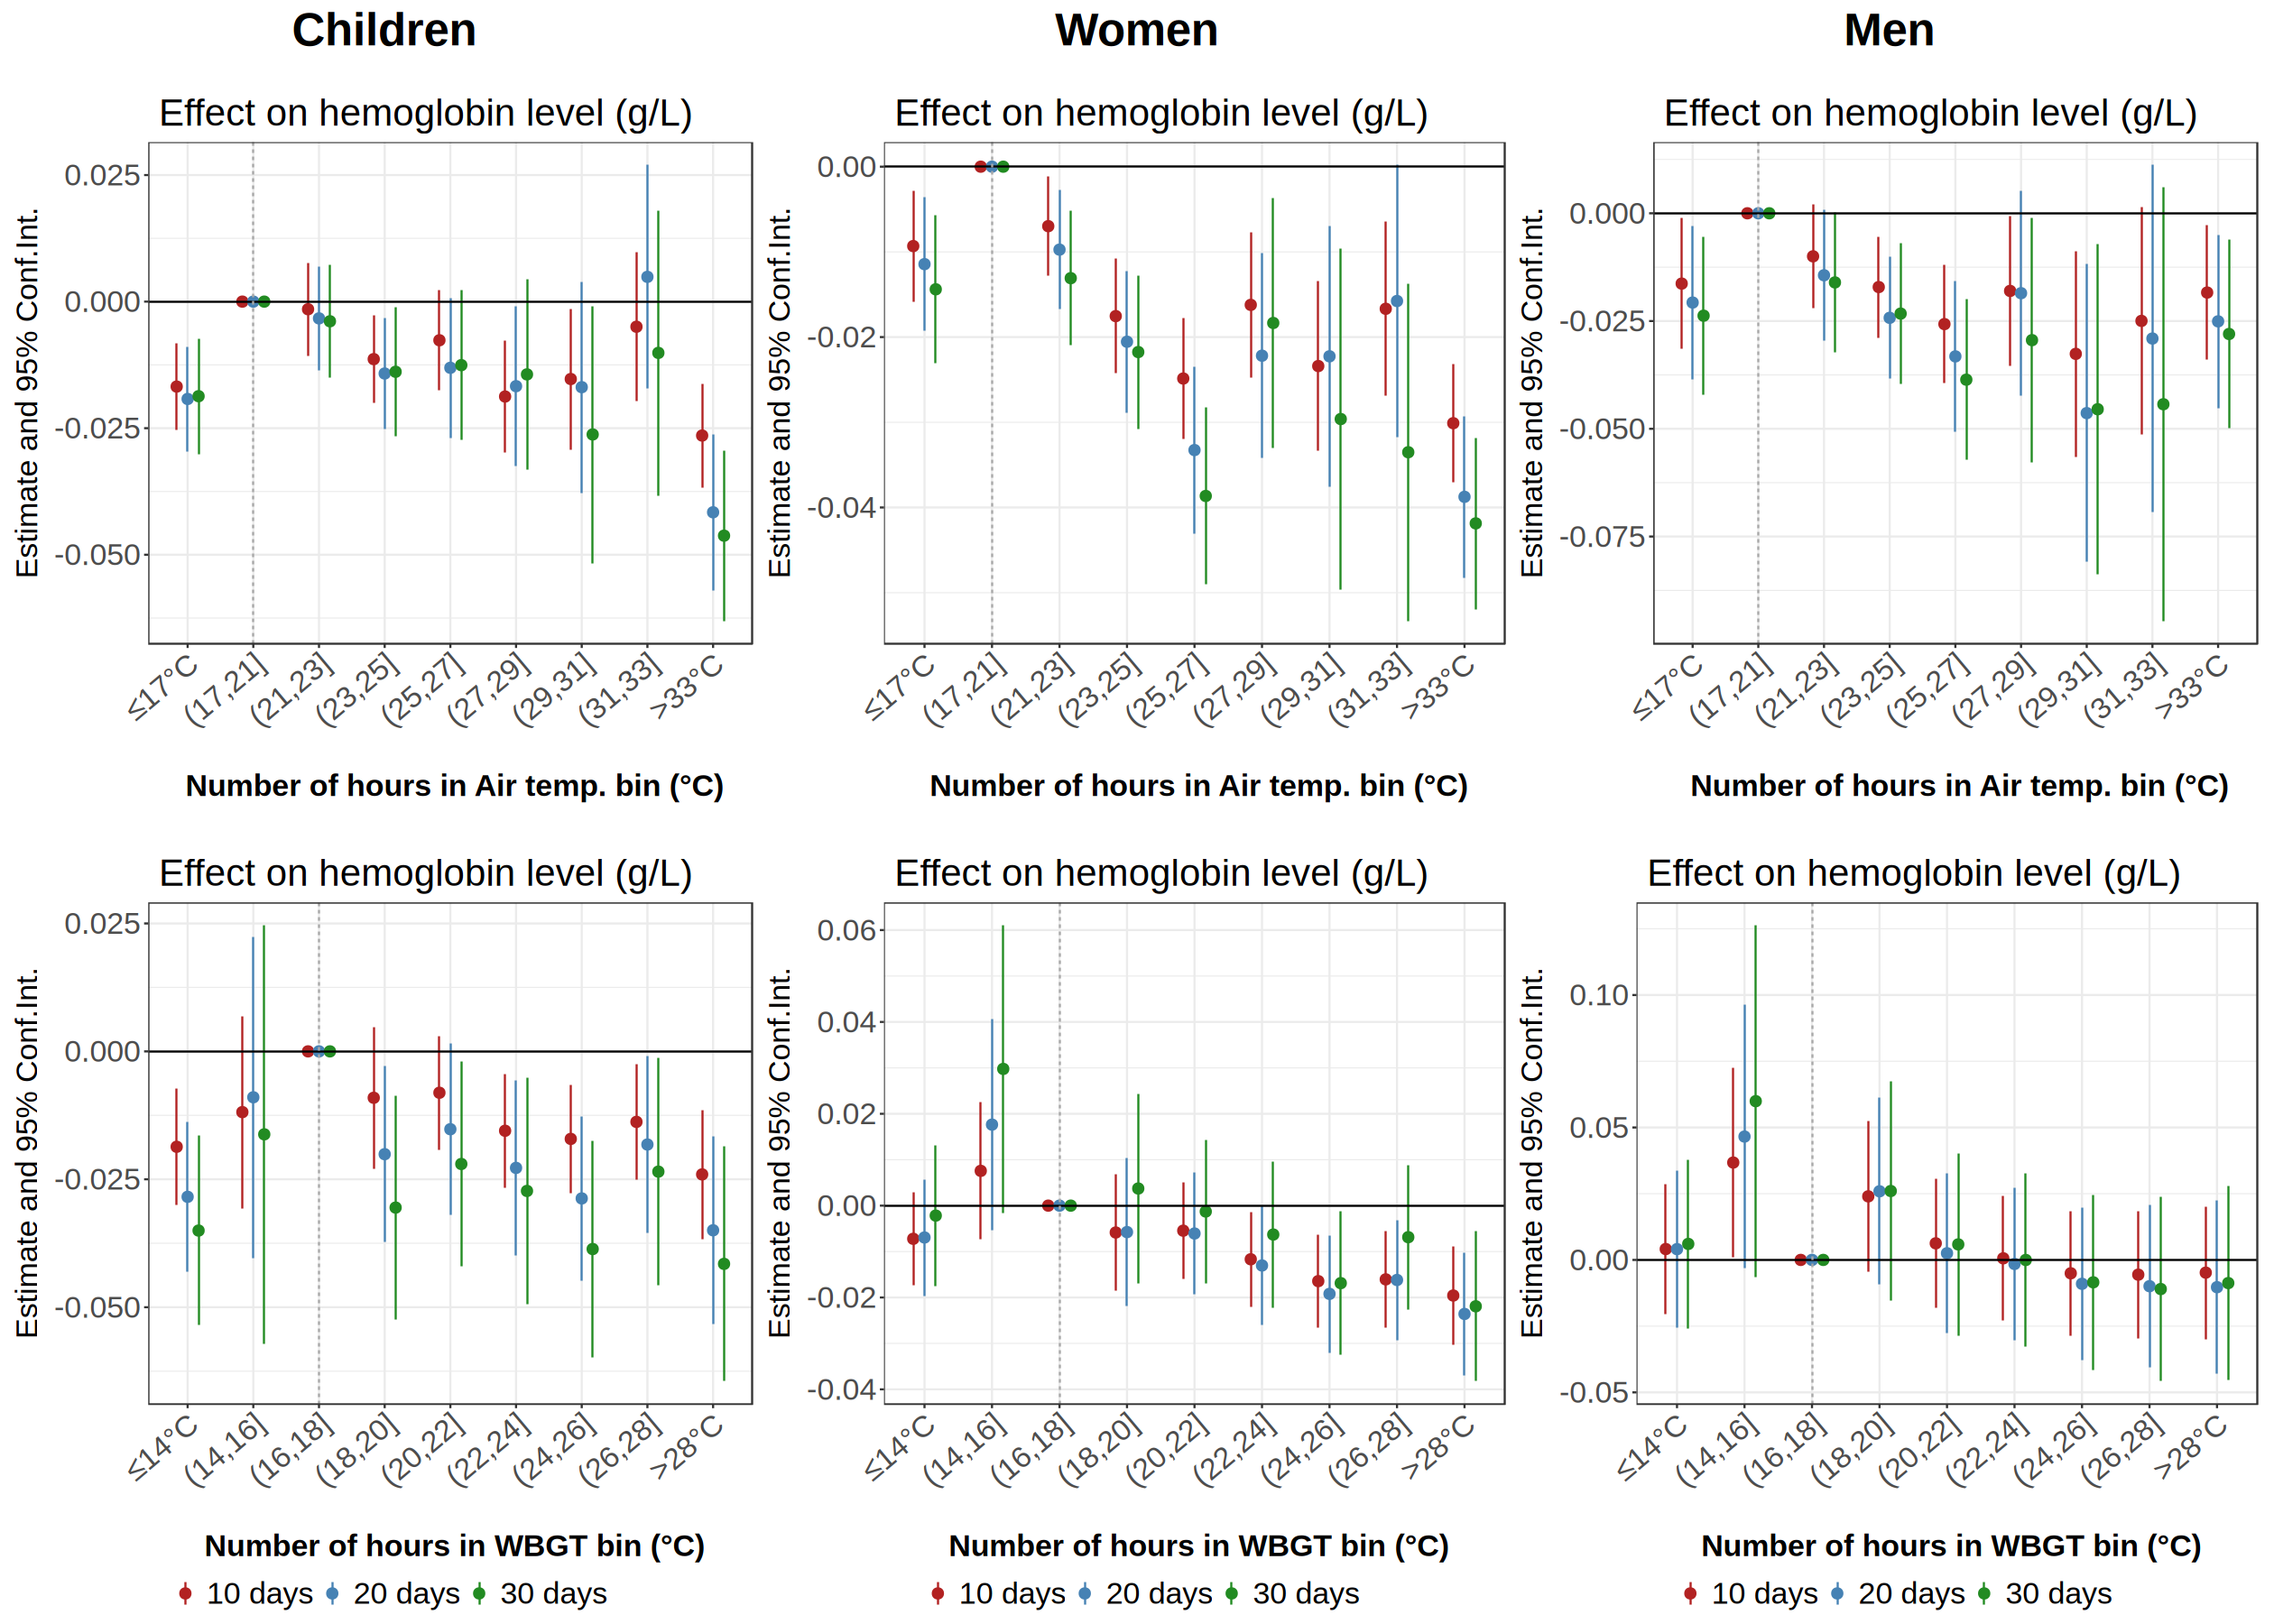

In [34]:
options(repr.plot.width=21, repr.plot.height=15, scipen=9999)

plot_all <- plot_children + plot_women + plot_men +  plot_layout(ncol=3)
plot_all

In [35]:
ggsave("./3_output/img/comp_estimates_Nhours.png", width=24, height=15, plot_all)